<a href="https://colab.research.google.com/github/RafaelPallo/projeto-equidade-educacional/blob/main/PROJETO_EQUIDADE_(Advanced_EdTech).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTS


In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import shape
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine

API PIB

In [ ]:
url = 'https://apisidra.ibge.gov.br/values/t/5938/n6/all/v/37/p/last%201'
response = requests.get(url)

if response.status_code == 200:
   data_PIB = response.json()
   df_PIB = pd.DataFrame(data_PIB)
   # transformar a primeira linha em cabeçalho
   df_PIB.columns = df_PIB.iloc[0]
   df_PIB = df_PIB[1:].reset_index(drop=True)
   # separar a tabela municipio com o código do estado
   df_PIB[['Cidade', 'Estado']] = df_PIB['Município'].str.split(' - ', expand=True)
   df_PIB['Cidade'] = df_PIB['Cidade'].str.strip()
   df_PIB['Estado'] = df_PIB['Estado'].str.strip()
   df_PIB = df_PIB.drop('Município',axis=1)

   display(df_PIB)


,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Município (Código),Variável (Código),Variável,Ano (Código),Ano,Cidade,Estado
0,6,Município,40,Mil Reais,1046343,1100015,37,Produto Interno Bruto a preços correntes,2023,2023,Alta Floresta D'Oeste,RO
1,6,Município,40,Mil Reais,4383815,1100023,37,Produto Interno Bruto a preços correntes,2023,2023,Ariquemes,RO
2,6,Município,40,Mil Reais,300832,1100031,37,Produto Interno Bruto a preços correntes,2023,2023,Cabixi,RO
3,6,Município,40,Mil Reais,3848468,1100049,37,Produto Interno Bruto a preços correntes,2023,2023,Cacoal,RO
4,6,Município,40,Mil Reais,1006389,1100056,37,Produto Interno Bruto a preços correntes,2023,2023,Cerejeiras,RO
...,...,...,...,...,...,...,...,...,...,...,...,...
5565,6,Município,40,Mil Reais,914943,5222005,37,Produto Interno Bruto a preços correntes,2023,2023,Vianópolis,GO
5566,6,Município,40,Mil Reais,677600,5222054,37,Produto Interno Bruto a preços correntes,2023,2023,Vicentinópolis,GO
5567,6,Município,40,Mil Reais,201846,5222203,37,Produto Interno Bruto a preços correntes,2023,2023,Vila Boa,GO
5568,6,Município,40,Mil Reais,444209,5222302,37,Produto Interno Bruto a preços correntes,2023,2023,Vila Propício,GO


API MUNICIPIOS

In [ ]:
url = "https://apisidra.ibge.gov.br/values/t/631/n1/all/n6/all/v/allxp/p/last%201/c2/0/c183/0/d/v93%200"
response = requests.get(url)

if response.status_code == 200:
   data_pop = response.json()
   df_populacao = pd.DataFrame(data_pop)
    # transformar a primeira linha em cabeçalho
   df_populacao.columns = df_populacao.iloc[0]
   df_populacao = df_populacao[1:].reset_index(drop=True)
   # separar a tabela municipio com o código do estado
   df_populacao[['Cidade', 'Estado']] = df_populacao['Brasil e Município'].str.split(' - ', expand=True)
   df_populacao['Cidade'] = df_populacao['Cidade'].str.strip()
   df_populacao['Estado'] = df_populacao['Estado'].str.strip()
   df_populacao = df_populacao.drop('Brasil e Município',axis=1)
   df_populacao = df_populacao[df_populacao['Brasil e Município (Código)'] != "1"]
   # df_pop_pib = df_populacao.merge(df_PIB, on='Município (Código)')
   display(df_populacao)


,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil e Município (Código),Variável (Código),Variável,Ano (Código),Ano,Sexo (Código),Sexo,Lugar de nascimento (Código),Lugar de nascimento,Cidade,Estado
1,6,Município,45,Pessoas,21494,1100015,93,População residente,2022,2022,0,Total,0,Total,Alta Floresta D'Oeste,RO
2,6,Município,45,Pessoas,96833,1100023,93,População residente,2022,2022,0,Total,0,Total,Ariquemes,RO
3,6,Município,45,Pessoas,5351,1100031,93,População residente,2022,2022,0,Total,0,Total,Cabixi,RO
4,6,Município,45,Pessoas,86887,1100049,93,População residente,2022,2022,0,Total,0,Total,Cacoal,RO
5,6,Município,45,Pessoas,15890,1100056,93,População residente,2022,2022,0,Total,0,Total,Cerejeiras,RO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5566,6,Município,45,Pessoas,14956,5222005,93,População residente,2022,2022,0,Total,0,Total,Vianópolis,GO
5567,6,Município,45,Pessoas,8768,5222054,93,População residente,2022,2022,0,Total,0,Total,Vicentinópolis,GO
5568,6,Município,45,Pessoas,4215,5222203,93,População residente,2022,2022,0,Total,0,Total,Vila Boa,GO
5569,6,Município,45,Pessoas,5815,5222302,93,População residente,2022,2022,0,Total,0,Total,Vila Propício,GO


Unir os Dataframes de PIB e população

In [ ]:
   df_pib_transfer = df_PIB[['Valor','Município (Código)']]
   df_pib_transfer = df_pib_transfer.rename(columns={"Município (Código)":"id_cidade","Valor":"valor_pib"})
   df_pib_transfer['valor_pib'] = df_pib_transfer['valor_pib'].astype(int)*1000
   #display(df_pib_transfer)
   df_pop_transfer = df_populacao[['Brasil e Município (Código)','Valor','Cidade','Estado']]
   df_pop_transfer = df_pop_transfer.rename(columns={"Valor":"valor_populacao","Brasil e Município (Código)":"id_cidade","Cidade":"cidade","Estado":"estado"})
   # display(df_pop_transfer)

   df_pop_pib = df_pop_transfer.merge(df_pib_transfer,on="id_cidade",how='inner',validate="one_to_one")
   df_pop_pib['pib_per_capta'] = (df_pop_pib['valor_pib'].astype(int) / df_pop_pib['valor_populacao'].astype(int))
   display(df_pop_pib)
   print(df_pop_pib['estado'].unique())


,id_cidade,valor_populacao,cidade,estado,valor_pib,pib_per_capta
0,1100015,21494,Alta Floresta D'Oeste,RO,1046343000,48680.701591
1,1100023,96833,Ariquemes,RO,4383815000,45271.911435
2,1100031,5351,Cabixi,RO,300832000,56219.772005
3,1100049,86887,Cacoal,RO,3848468000,44292.794089
4,1100056,15890,Cerejeiras,RO,1006389000,63334.738829
...,...,...,...,...,...,...
5565,5222005,14956,Vianópolis,GO,914943000,61175.648569
5566,5222054,8768,Vicentinópolis,GO,677600000,77281.021898
5567,5222203,4215,Vila Boa,GO,201846000,47887.544484
5568,5222302,5815,Vila Propício,GO,444209000,76390.197764


['RO' 'AC' 'AM' 'RR' 'PA' 'AP' 'TO' 'MA' 'PI' 'CE' 'RN' 'PB' 'PE' 'AL'
 'SE' 'BA' 'MG' 'ES' 'RJ' 'SP' 'PR' 'SC' 'RS' 'MS' 'MT' 'GO' 'DF']


Arrumando Microdados Enem Equidade


In [ ]:
df_enem = pd.read_csv('/content/microdados_enem_equidade.csv')
df_enem = df_enem.rename(columns={'municipio':'cidade'})
print(df_enem['cidade'].unique())
df_enem = df_enem.merge(
    df_pop_pib[['id_cidade','cidade', 'estado','pib_per_capta']],
    on='cidade',
    how='left'
)
display(df_enem)

['Belo Horizonte' 'Fortaleza' 'Manaus' 'Rio de Janeiro' 'São Paulo']


,ID_Inscricao,cidade,Q006_Renda,Score_Renda,Q002_Escolaridade_Mae,Score_Escolaridade,Q025_Tem_Internet,Score_Internet,NU_NOTA_GERAL,ISE,id_cidade,estado,pib_per_capta
0,3563451924,Belo Horizonte,E,4,G,5,Sim,1,711,10,3106200,MG,56227.293182
1,9678344341,Fortaleza,C,2,F,3,Sim,1,591,6,2304400,CE,35796.741313
2,5298312065,Manaus,Q,5,G,4,Sim,1,692,10,1302603,AM,61855.151140
3,2250819632,Belo Horizonte,C,2,F,3,Sim,1,572,6,3106200,MG,56227.293182
4,5684118973,Fortaleza,D,3,F,3,Sim,1,559,7,2304400,CE,35796.741313
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3843815297,São Paulo,C,2,F,3,Sim,1,669,6,3550308,SP,93156.234558
2496,2288246472,Rio de Janeiro,B,1,A,0,Não,0,426,1,3304557,RJ,67371.974891
2497,3421149011,Fortaleza,E,4,G,4,Sim,1,727,9,2304400,CE,35796.741313
2498,5498466015,Belo Horizonte,B,1,B,1,Sim,1,357,3,3106200,MG,56227.293182


Calculo ISE

In [ ]:
# 2. Limpeza e Transformação (Feature Engineering)
# Mapeamento qualitativo para quantitativo conforme padrões do INEP
mapping_renda = {chr(i): i-65 for i in range(65, 82)} # A=0, B=1, ..., Q=16
mapping_esc = {chr(i): i-65 for i in range(65, 73)}   # A=0, B=1, ...

df_enem['Renda_Num'] = df_enem['Q006_Renda'].map(mapping_renda)
df_enem['Escolaridade_Mae_Num'] = df_enem['Q002_Escolaridade_Mae'].map(mapping_esc)
df_enem['Tem_Internet'] = df_enem['Q025_Tem_Internet'].map({'Sim': 1, 'Não': 0})

# Criação do Índice Socioeconômico (ISE) - Média normalizada
features = ['Renda_Num', 'Escolaridade_Mae_Num', 'Tem_Internet']
df_enem['ISE'] = df_enem[features].mean(axis=1)
print(df_enem['ISE'])

0       3.666667
1       2.666667
2       7.666667
3       2.666667
4       3.000000
          ...   
2495    2.666667
2496    0.333333
2497    3.666667
2498    1.000000
2499    0.666667
Name: ISE, Length: 2500, dtype: float64


Regressão Linar Nota Esperada


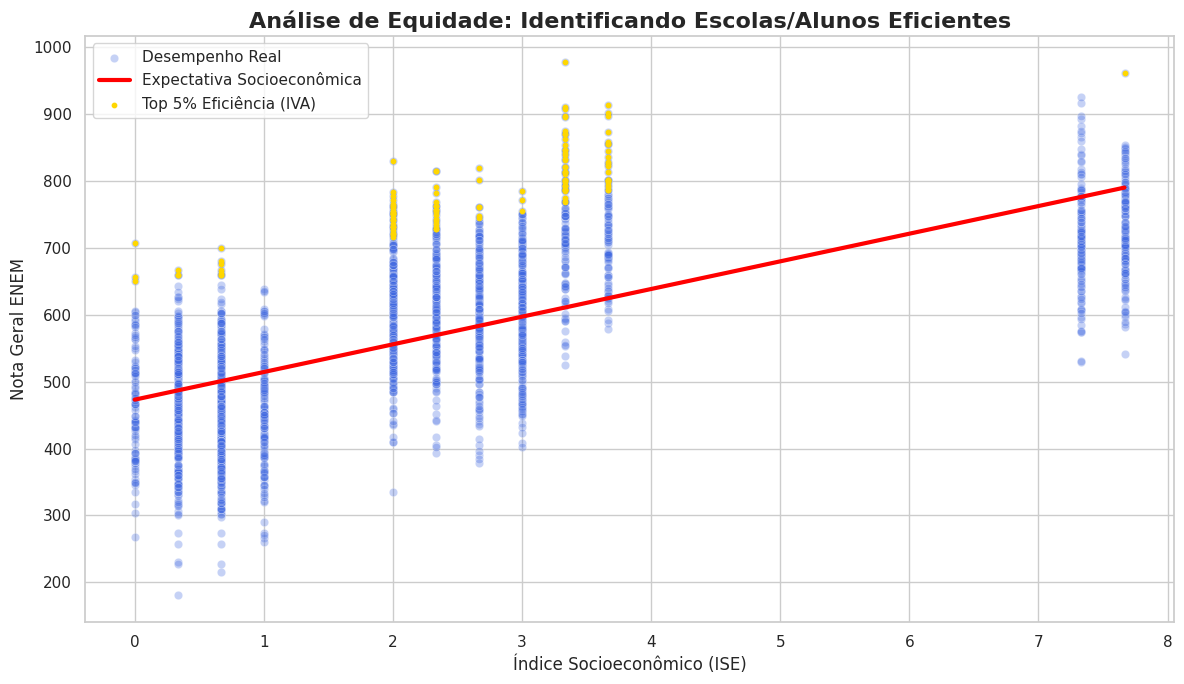

Ranking de Eficiência (Top 5):
      ID_Inscricao       ISE  NU_NOTA_GERAL         IVA
872     5919951522  3.333333            977  366.135029
2314    3364347146  3.333333            910  299.678231
1048    3253450385  3.333333            908  297.678231
239     2712930785  3.666667            913  288.356490
2108    1359954495  3.333333            897  286.020028


In [28]:

# 1. LIMPEZA E ENGENHARIA DE DADOS (ETL)
# Mapeamento qualitativo para quantitativo (INEP)
mapping_renda = {chr(i): i-65 for i in range(65, 82)}
mapping_esc = {chr(i): i-65 for i in range(65, 73)}

df_enem['Renda_Num'] = df_enem['Q006_Renda'].map(mapping_renda)
df_enem['Escolaridade_Mae_Num'] = df_enem['Q002_Escolaridade_Mae'].map(mapping_esc)
df_enem['Tem_Internet'] = df_enem['Q025_Tem_Internet'].map({'Sim': 1, 'Não': 0})

# Criando o ISE (Índice Socioeconômico)
features = ['Renda_Num', 'Escolaridade_Mae_Num', 'Tem_Internet']
df_enem['ISE'] = df_enem[features].mean(axis=1)

# Remover valores nulos para não quebrar a regressão
df_clean = df_enem.dropna(subset=['ISE', 'NU_NOTA_GERAL'])

# 3. RIGOR ESTATÍSTICO: NORMALIZAÇÃO E MODELAGEM
scaler = StandardScaler()
X = df_clean[['ISE','pib_per_capta']]
y = df_clean['NU_NOTA_GERAL']

# Normalizamos o ISE para a regressão (requisito do PDF)
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

# Calculando a Nota Esperada e o IVA (Resíduo)
df_clean['Nota_Esperada'] = model.predict(X_scaled)
df_clean['IVA'] = df_clean['NU_NOTA_GERAL'] - df_clean['Nota_Esperada']

# 4. VISUALIZAÇÃO PARA O SECRETÁRIO
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Gráfico de Dispersão com Linha de Tendência
sns.scatterplot(data=df_clean, x='ISE', y='NU_NOTA_GERAL', alpha=0.3, color='royalblue', label='Desempenho Real')
sns.lineplot(x=df_clean['ISE'], y=df_clean['Nota_Esperada'], color='red', linewidth=3, label='Expectativa Socioeconômica')

# Destaque para os "Diamantes Brutos" (Alta Eficiência)
top_eficiencia = df_clean[df_clean['IVA'] > df_clean['IVA'].quantile(0.95)]
plt.scatter(top_eficiencia['ISE'], top_eficiencia['NU_NOTA_GERAL'], color='gold', s=10, label='Top 5% Eficiência (IVA)')

plt.title('Análise de Equidade: Identificando Escolas/Alunos Eficientes', fontsize=16, fontweight='bold')
plt.xlabel('Índice Socioeconômico (ISE)', fontsize=12)
plt.ylabel('Nota Geral ENEM', fontsize=12)
plt.legend()
plt.tight_layout()

plt.show()

# 5. RESULTADO FINAL (Top 5 cidades/escolas por eficiência para o slide)
print("Ranking de Eficiência (Top 5):")
print(df_clean[['ID_Inscricao', 'ISE', 'NU_NOTA_GERAL', 'IVA']].sort_values(by='IVA', ascending=False).head())

Gráfico Apresentação dos dados do valor adicionado

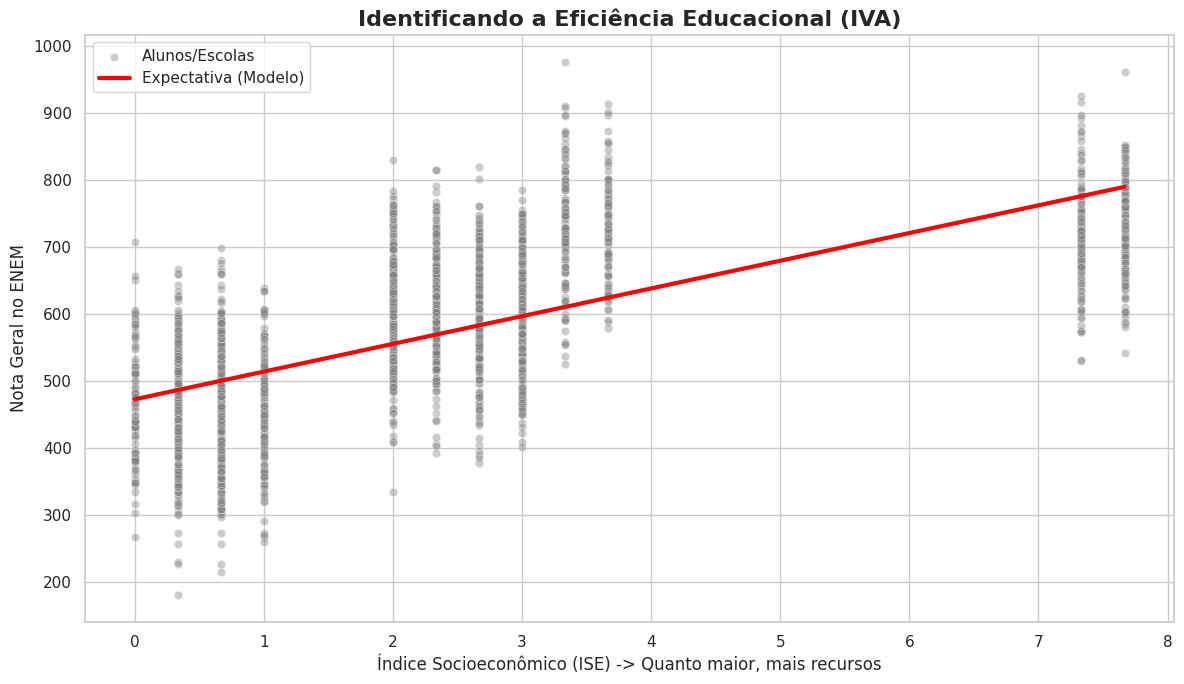

In [ ]:
# Configurando o estilo visual para a apresentação
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 1. Gráfico de Dispersão (Dados Reais)
sns.scatterplot(data=df_clean, x='ISE', y='NU_NOTA_GERAL', alpha=0.4, label='Alunos/Escolas', color='gray')

# 2. Linha de Regressão (Expectativa)
sns.lineplot(x=df_clean['ISE'], y=df_clean['Nota_Esperada'], color='red', label='Expectativa (Modelo)', linewidth=3)

# Customização de títulos para o "público político"
plt.title('Identificando a Eficiência Educacional (IVA)', fontsize=16, fontweight='bold')
plt.xlabel('Índice Socioeconômico (ISE) -> Quanto maior, mais recursos', fontsize=12)
plt.ylabel('Nota Geral no ENEM', fontsize=12)
plt.legend()

# Exibição
plt.tight_layout()
plt.show()

Adicionando Latitude e Longitude

In [31]:

malhas = {}

for cidade in df_clean['id_cidade'].unique():
    url = f'https://servicodados.ibge.gov.br/api/v4/malhas/municipios/{cidade}?formato=application/vnd.geo+json'
    geojson = requests.get(url).json()

    gdf = gpd.GeoDataFrame.from_features(geojson['features'])
    centroide = gdf.geometry.centroid.iloc[0]

    lat = centroide.y
    lon = centroide.x
    df_clean.loc[df_clean['id_cidade'] == cidade, 'latitude'] = lat
    df_clean.loc[df_clean['id_cidade'] == cidade, 'longitude'] = lon

,ID_Inscricao,cidade,Q006_Renda,Score_Renda,Q002_Escolaridade_Mae,Score_Escolaridade,Q025_Tem_Internet,Score_Internet,NU_NOTA_GERAL,ISE,id_cidade,estado,pib_per_capta,Renda_Num,Escolaridade_Mae_Num,Tem_Internet,Nota_Esperada,IVA,latitude,longitude
0,3563451924,Belo Horizonte,E,4,G,5,Sim,1,711,3.666667,3106200,MG,56227.293182,4,6,1,624.526194,86.473806,-19.902696,-43.959994
1,9678344341,Fortaleza,C,2,F,3,Sim,1,591,2.666667,2304400,CE,35796.741313,2,5,1,582.764691,8.235309,-3.785866,-38.528003
2,5298312065,Manaus,Q,5,G,4,Sim,1,692,7.666667,1302603,AM,61855.151140,16,6,1,789.985978,-97.985978,-2.625919,-60.259633
3,2250819632,Belo Horizonte,C,2,F,3,Sim,1,572,2.666667,3106200,MG,56227.293182,2,5,1,583.190577,-11.190577,-19.902696,-43.959994
4,5684118973,Fortaleza,D,3,F,3,Sim,1,559,3.000000,2304400,CE,35796.741313,3,5,1,596.543230,-37.543230,-3.785866,-38.528003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3843815297,São Paulo,C,2,F,3,Sim,1,669,2.666667,3550308,SP,93156.234558,2,5,1,583.960381,85.039619,-23.650051,-46.648095
2496,2288246472,Rio de Janeiro,B,1,A,0,Não,0,426,0.333333,3304557,RJ,67371.974891,1,0,0,486.973121,-60.973121,-22.923165,-43.451094
2497,3421149011,Fortaleza,E,4,G,4,Sim,1,727,3.666667,2304400,CE,35796.741313,4,6,1,624.100308,102.899692,-3.785866,-38.528003
2498,5498466015,Belo Horizonte,B,1,B,1,Sim,1,357,1.000000,3106200,MG,56227.293182,1,1,1,514.297882,-157.297882,-19.902696,-43.959994


Tratamento final de dados
